# 38 - RMSprop and Adam

**Section:** Metaparameters | **Prereqs:** `Metaparameters/SGDwithMomentum.ipynb` | **Next:** `Metaparameters/AdamwithL2.ipynb`

Momentum smooths the *direction* of the step. RMSprop rescales its *size*, per
parameter. Adam does both.

| Optimizer | First moment (mean of gradients) | Second moment (mean of squared gradients) |
|---|---|---|
| SGD | - | - |
| SGD + momentum | yes | - |
| RMSprop | - | yes |
| **Adam** | yes | yes |

**RMSprop's idea:** divide each parameter's step by the square root of its recent
squared gradient. A parameter with consistently huge gradients takes smaller
steps; one with tiny gradients takes bigger ones. Every parameter ends up with
its own effective learning rate.

**Adam** = momentum + RMSprop + a bias correction for the first few steps. It is
the default for good reason: it works acceptably across a wide range of learning
rates, which is exactly what this notebook's 3 x 20 sweep shows.

**The result to read off the plot:** Adam and RMSprop hold high accuracy across
two orders of magnitude of learning rate, while SGD only works in a narrow band
at the high end. Adam is not more accurate - it is more forgiving. When you have
time to tune, well-tuned SGD with momentum still wins on many vision tasks.

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset

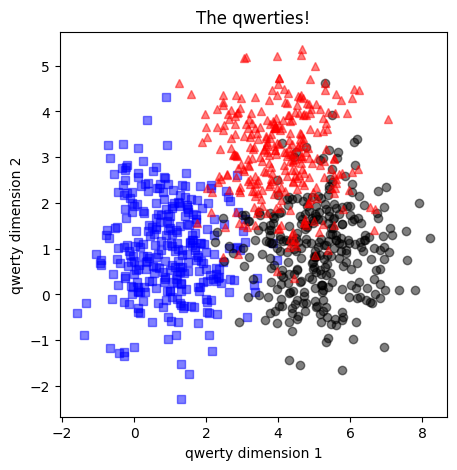

In [134]:
# The same three-cluster problem, so results are comparable with the momentum
# notebook.
nPerClust = 300
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]
C = [ 4, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.hstack((  np.zeros((nPerClust)),
                         np.ones( (nPerClust)),
                       1+np.ones( (nPerClust))  ))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long() # note: "long" format for CCE

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^',alpha=.5)
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [135]:
# 90/10 split, batches of 16.
from sklearn.model_selection import train_test_split
train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# finally, translate into dataloader objects
batchsize    = 16
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [136]:
# Model factory returning the requested optimizer.
# Defaults worth knowing: Adam's betas are (0.9, 0.999) - the first for the
# gradient average, the second for the squared-gradient average - and eps=1e-8
# guards the division. You rarely need to change any of them.
epochs = 50


def create_model(name,lr):
  model = nn.Sequential (
      nn.Linear(2,32),
      nn.ReLU(),
      nn.Linear(32,32),
      nn.ReLU(),
      nn.Linear(32,3)
  )

  lossFunc = nn.CrossEntropyLoss()


  optimizers = {
      "Adam": torch.optim.Adam(model.parameters(), lr=lr),
      "SGD" : torch.optim.SGD(model.parameters(), lr=lr),
      "RMSprop" : torch.optim.RMSprop(model.parameters(), lr=lr)
  }



  return model, lossFunc, optimizers[name]


In [137]:
# Standard training function taking (optimizer name, learning rate).
def train_model(name,lr):

  classifier , lossFunc, optimizer = create_model(name,lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)

  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []


    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()))

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y).float()))


  return train_acc, test_acc, losses


In [138]:
# The sweep: 3 optimizers x 20 log-spaced learning rates = 60 runs.
# Log spacing again, because learning rate matters by order of magnitude.
optims = ["SGD","Adam","RMSprop"]
learning_rates = np.logspace(np.log10(0.0001),np.log10(0.1),20)

SGD_acc = []
Adam_acc = []
RMSprop_acc = []


for i in range(len(optims)):
  for lr in learning_rates:
      train ,test, loss = train_model(optims[i],lr)
      if optims[i] == "SGD":
        SGD_acc.append(test[-1])
      elif optims[i] == "Adam":
        Adam_acc.append(test[-1])
      else:
        RMSprop_acc.append(test[-1])

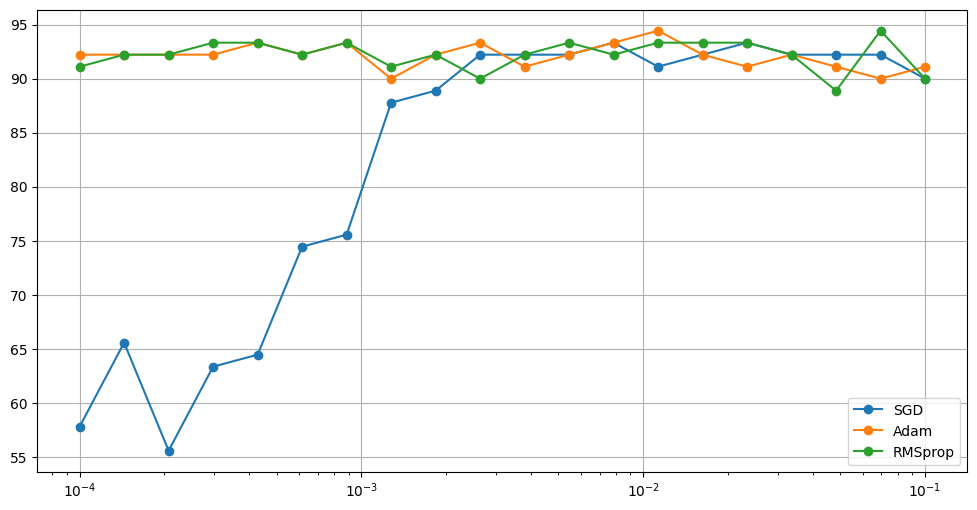

In [139]:
# The headline plot. What to read from it:
#   - SGD:     a narrow usable band, needing a large lr,
#   - RMSprop/Adam: high accuracy across a wide band, then divergence when the
#                   lr gets too large.
# The WIDTH of each curve's plateau is the practical message - it is how much
# tuning that optimizer will demand of you.
fig,ax = plt.subplots(figsize=(12,6))
ax.plot(learning_rates, SGD_acc,"o-", label="SGD")
ax.plot(learning_rates, Adam_acc, "o-", label="Adam")
ax.plot(learning_rates, RMSprop_acc,"o-", label="RMSprop")
ax.set_xscale('log')


ax.grid();
ax.legend();